加载数据

In [1]:
import scipy.io as sio

In [2]:
wrapped_mat_path = r"data/wrapped/wrapped.mat"
gt_mat_path = r"data/gt/gt.mat"

In [3]:
wrapped_mat = sio.loadmat(wrapped_mat_path)['input']
gt_mat = sio.loadmat(gt_mat_path)['gt']

展示Wrapped与GT_Unwrapped

In [29]:
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.ticker import MultipleLocator, FuncFormatter
def pi_formatter(x, pos):
    k = x / np.pi

    # 0
    if np.isclose(k, 0):
        return "0"

    # 接近整数倍 π
    if np.isclose(k, round(k)):
        k_int = int(round(k))
        if k_int == 1:
            return r"$\pi$"
        elif k_int == -1:
            return r"$-\pi$"
        else:
            return rf"${k_int}\pi$"

    # 非整数倍：显示数值（可改精度）
    return rf"${x:.2f}$"

In [ ]:
# 期刊要求
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    # latex
    # "text.usetex": True,
    # "font.family": "serif"
})

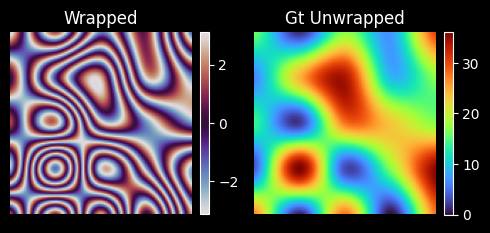

In [31]:
fig_dpi = 600
fig_size_raw = 3.5
fig_size_col = 2.5
img_path = r"res/res1/figure.pdf"
raw = 1
col = 2
fig, axes = plt.subplots(raw, col, figsize=(fig_size_col * col, fig_size_raw * raw))
axes = axes.flatten()

# raw 1, col 1
ax_0 = axes[0]
im_0 = ax_0.imshow(wrapped_mat, cmap="twilight")
ax_0.set_title("Wrapped")
ax_0.axis("off")
# ax_0.legend(frameon=False)
cbar = fig.colorbar(im_0, ax=ax_0, fraction=0.046, pad=0.04)
# cbar.locator = MultipleLocator(np.pi)
# cbar.formatter = FuncFormatter(pi_formatter)
# cbar.update_ticks()

# raw 1, col 2
ax_1 = axes[1]
im_1 = ax_1.imshow(gt_mat, cmap="turbo")
ax_1.set_title("Gt Unwrapped")
ax_1.axis("off")
# ax_1.legend(frameon=False)
cbar = fig.colorbar(im_1, ax=ax_1, fraction=0.046, pad=0.04)
# cbar.locator = MultipleLocator(np.pi)
# cbar.formatter = FuncFormatter(pi_formatter)
# cbar.update_ticks()

fig.tight_layout()
fig.savefig(img_path, dpi=fig_dpi, bbox_inches="tight", pad_inches=0)
plt.show(fig)
# plt.close(fig)

PUNet Pred

In [ ]:
import torch

In [ ]:
punet_pred_batch_path = "data/punet/pred_samples_0_1.pt"

In [ ]:
# keys: wrapped, gt_unwrapped, pred_unwrapped, diff_unwrapped
punet_pred_batch_pt = torch.load(punet_pred_batch_path)

In [ ]:
punet_pred = punet_pred_batch_pt['pred_unwrapped']

SqdLstm Pred

In [ ]:
sqd_lstm_pred_batch_path = "data/sqd_lstm/pred_samples_0_1.pt"

In [ ]:
# keys: wrapped, gt_unwrapped, pred_unwrapped, diff_unwrapped
sqd_lstm_pred_batch_pt = torch.load(punet_pred_batch_path)

In [ ]:
sqd_lstm_pred = sqd_lstm_pred_batch_pt['pred_unwrapped']

Restormer Pred

In [32]:
restormer_pred_batch_path = "data/restormer/pred_samples_0_1.pt"

In [33]:
# keys: wrapped, gt_unwrapped, pred_unwrapped, diff_unwrapped
restormer_pred_batch_pt = torch.load(punet_pred_batch_path)

/tmp/ipykernel_1435035/1084532101.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  restormer_pred_batch_pt = torch.load(punet_pred_batch_path)


In [34]:
restormer_pred = sqd_lstm_pred_batch_pt['pred_unwrapped']

展示对比结果

In [35]:
# tensor to numpy 2d
def _to_numpy_2d(x: torch.Tensor):
    return x.detach().cpu().squeeze().numpy()
# def _to_numpy_2d(x: torch.Tensor):
#     return x.squeeze()

In [46]:
titles = [
    "Wrapped", "GT", "PUNet",
    "SQD-LSTM", "Restormer",
    "Wrapped", "GT",
    "Diff PUNet", "Diff SQD-LSTM",
    "Diff Restormer"
]
imgs = [
    wrapped_mat, gt_mat, _to_numpy_2d(punet_pred), _to_numpy_2d(sqd_lstm_pred), _to_numpy_2d(restormer_pred),
    wrapped_mat, gt_mat,
    gt_mat - _to_numpy_2d(punet_pred),
    gt_mat - _to_numpy_2d(sqd_lstm_pred),
    gt_mat - _to_numpy_2d(restormer_pred)
]
cmaps = [
    "twilight", "turbo", "turbo",
    "turbo", "turbo",
    "twilight", "turbo",
    "inferno", "inferno", "inferno"
]

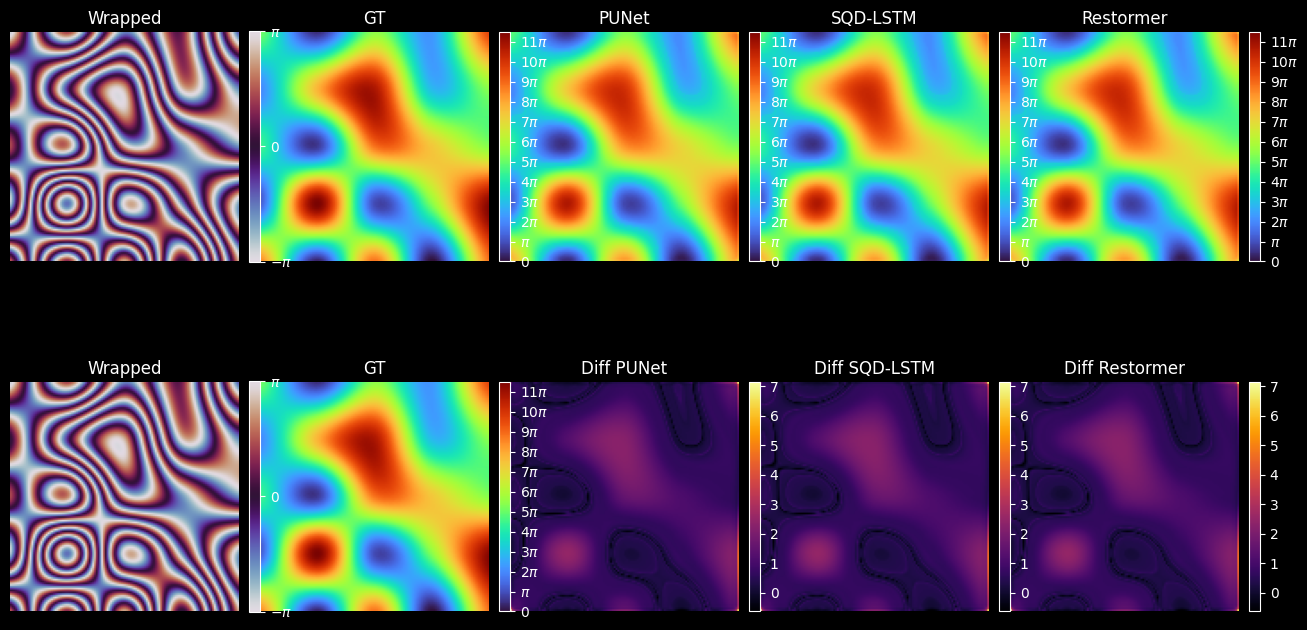

In [65]:
fig_dpi = 600
fig_size_raw = 3.5
fig_size_col = 2.5
img_path = r"res/res2/figure.pdf"
raw = 2
col = 5
fig, axes = plt.subplots(raw, col, figsize=(fig_size_col * col, fig_size_raw * raw))
# fig, axes = plt.subplots(raw, col, figsize=(fig_size_raw * col, fig_size_col * raw))
axes = axes.flatten()
# # 关闭不必要的边距
# for ax in axes:
#     ax.set_xmargin(0)   # 关闭X轴边距
#     ax.set_ymargin(0)   # 关闭Y轴边距
zip_list = list(zip(axes, imgs, titles, cmaps))
# wrapped
color_norm = colors.Normalize(vmin=-np.pi, vmax=np.pi)
for ax, img, title, cmap in  zip_list[:1]+zip_list[5:6]:
    im = ax.imshow(img, cmap=cmap, norm=color_norm)
    ax.set_title(title)
    ax.axis("off")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.locator = MultipleLocator(np.pi)
    cbar.formatter = FuncFormatter(pi_formatter)
    cbar.update_ticks()
    # cbar.ax.tick_params(labelsize=7)
    # cbar.outline.set_visible(False)
# gt, punet, sqd-lstm
color_norm = colors.Normalize(vmin=0)
ims = []
for ax, img, title, cmap in zip_list[1:5] + zip_list[6:7]:
    # im = ax.imshow(img, cmap=cmap)
    im = ax.imshow(img, cmap=cmap, norm=color_norm)
    ax.set_title(title)
    ax.axis("off")
    ims.append(im)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.locator = MultipleLocator(np.pi)
    cbar.formatter = FuncFormatter(pi_formatter)
    cbar.update_ticks()
    # cbar.ax.tick_params(labelsize=7)
    # cbar.outline.set_visible(False)
for ax, img, title, cmap in zip_list[7:]:
    im = ax.imshow(img, cmap=cmap)
    # im = ax.imshow(img, cmap=cmap, norm=color_norm)
    ax.set_title(title)
    ax.axis("off")
    ims.append(im)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # cbar.locator = MultipleLocator(np.pi)
    # cbar.formatter = FuncFormatter(pi_formatter)
    # cbar.update_ticks()
# fig.tight_layout()

# fig.tight_layout(
#     pad=0,        # 整个图形边缘的填充
#     w_pad=0,      # 水平方向子图之间的填充
#     h_pad=0,      # 垂直方向子图之间的填充
#     rect=[0, 0, 0, 0]  # 子图区域在图形中的位置 [左, 下, 右, 上]
# )


plt.subplots_adjust(
    left=0.0,      # 没有左边距
    right=1.0,     # 没有右边距
    top=1.0,       # 没有上边距
    bottom=0.0,    # 没有下边距
    hspace=0.0,    # 没有垂直间距
    wspace=0.0     # 没有水平间距
)
fig.savefig(img_path, dpi=fig_dpi, bbox_inches="tight", pad_inches=0)
plt.show(fig)

In [ ]:
# fig_dpi = 600
# fig_size_raw = 3.5
# fig_size_col = 2.5
# img_path = r"res/res2/figure.pdf"
# raw = 1
# col = 4
# fig, axes = plt.subplots(
#     raw, col,
#     figsize=(fig_size_col * col, fig_size_raw * raw),
#     constrained_layout=True  # 启用自动布局调整
# )
# axes = axes.flatten()
# zip_list = list(zip(axes, imgs, titles, cmaps))
# # wrapped
# color_norm0 = colors.Normalize(vmin=-np.pi, vmax=np.pi)
# # 主刻度：每 π 一个
# im0 = axes[0].imshow(imgs[0], cmap=cmaps[0], norm=color_norm0)
# axes[0].set_title(titles[0])
# axes[0].axis("off")
# cbar0 = fig.colorbar(im0, ax=axes[0], orientation="horizontal", fraction=0.046, pad=0.04)
# cbar0.locator = MultipleLocator(np.pi)
# cbar0.formatter = FuncFormatter(pi_formatter)
# cbar0.update_ticks()
# cbar0.ax.tick_params(labelsize=7)
# cbar0.outline.set_visible(False)
# # cbar0.ax.set_box_aspect(0.08)
# # gt, punet, sqd-lstm
# color_norm = colors.Normalize(vmin=0)
# ims = []
# for ax, img, title, cmap in zip_list[1:]:
#     # im = ax.imshow(img, cmap=cmap)
#     im = ax.imshow(img, cmap=cmap, norm=color_norm)
#     ax.set_title(title)
#     ax.axis("off")
#     ims.append(im)
# # cax1 = fig.add_subplot(gs[1, 1:])
# cbar1 = fig.colorbar(ims[0], ax=axes[1:], orientation="horizontal", shrink=0.3)
# cbar1.locator = MultipleLocator(np.pi)
# cbar1.formatter = FuncFormatter(pi_formatter)
# cbar1.update_ticks()
# cbar1.ax.tick_params(labelsize=7)
# cbar1.outline.set_visible(False)
# # cbar1.ax.set_box_aspect(0.08)
# # fig.tight_layout()
# fig.savefig(img_path, dpi=fig_dpi, bbox_inches="tight")
# plt.show(fig)

添加噪声

In [48]:
import tqdm
from diffusers import DDPMScheduler

/home/lbxu/xiangyu.liu/envs/DMForPU2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [54]:
fig_size_raw = 3.5
fig_size_col = 2.5
gt_tensor = torch.from_numpy(gt_mat).unsqueeze(0).unsqueeze(0).float()  # [1, 1, H, W]
noise = torch.randn_like(gt_tensor)
scheduler = DDPMScheduler(num_train_timesteps=10)
img_path_dir = r"res/res4"
for t in tqdm.tqdm(scheduler.timesteps, desc="Sampling"):
    noisy = scheduler.add_noise(gt_tensor, noise, t)
    img = noisy.squeeze()  # [H, W]
    img = img.detach().cpu().numpy()
    img_path = f"{img_path_dir}/noisy_t{t}.png"
    fig= plt.figure(figsize=(fig_size_col, fig_size_raw))
    plt.imshow(img, cmap="turbo")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(img_path, dpi=fig_dpi, bbox_inches="tight", pad_inches=0)
    plt.close()

Sampling: 100%|██████████| 10/10 [00:02<00:00,  3.64it/s]
